In [1]:
from FEM import FEM_time_integrate as FEM

In [2]:
def scaling_function(x):
    return 0.5 / 18**2 * (x-18)**2 + 0.5

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib import animation

# --- Utility Functions ---

def beam_element_stiffness_matrix(EI, h):
    factor = EI / h**3
    Ke = factor * np.array([
        [12,        6*h,       -12,       6*h],
        [6*h,    4*h**2,    -6*h,    2*h**2],
        [-12,     -6*h,       12,       -6*h],
        [6*h,    2*h**2,    -6*h,    4*h**2]
    ])
    return Ke


def beam_element_mass_matrix(rho, h):
    factor = (rho * h) / 420.0
    Me = factor * np.array([
        [156, 22 * h, 54, -13 * h],
        [22 * h, 4 * h**2, 13 * h, -3 * h**2],
        [54, 13 * h, 156, -22 * h],
        [-13 * h, -3 * h**2, -22 * h, 4 * h**2]
    ])
    return Me


def shape_function_interpolate(dofs, x_left, x_right, x_local_array):
    a = x_left
    b = x_right
    h_element = b - a
    dofs_reshaped = np.array(dofs).reshape(-1, 1)
    s = x_local_array / h_element
    s2 = s * s
    s3 = s * s2
    N1 = 1 - 3*s2 + 2*s3
    N2 = h_element * (s - 2*s2 + s3)
    N3 = 3*s2 - 2*s3
    N4 = h_element * (-s2 + s3)
    interpolated_values = (
        dofs_reshaped[0] * N1 +
        dofs_reshaped[1] * N2 +
        dofs_reshaped[2] * N3 +
        dofs_reshaped[3] * N4
    )
    return interpolated_values


def shape_function_values(xF, h):
    s = xF / h
    s2 = s * s
    s3 = s * s2
    N1 = 1 - 3*s2 + 2*s3
    N2 = h * (s - 2*s2 + s3)
    N3 = 3*s2 - 2*s3
    N4 = h * (-s2 + s3)
    return (N1, N2, N3, N4)


def newmark_beta_timestep(
    u_cur, v_cur, a_cur,
    M_red, C_red, K_red, f_next_red, dt,
    beta=0.25, gamma=0.5
):
    c1 = 1 / (beta * dt**2)
    c2 = gamma / (beta * dt)
    c3 = 1 / (beta * dt)
    c4 = 1 / (2 * beta) - 1
    c5 = 1 - (gamma / beta)
    c6 = dt * (1 - (gamma / (2 * beta)))
    lhs_red = M_red * c1 + C_red * c2 + K_red
    rhs_red = f_next_red + M_red @ (u_cur * c1 + v_cur * c3 + a_cur * c4) + C_red @ (u_cur * c2 + v_cur * c5 + a_cur * c6)
    u_next_red = np.linalg.solve(lhs_red, rhs_red)
    a_next_red = c1 * (u_next_red - u_cur) - v_cur * c3  - a_cur * c4
    v_next_red = c2 * (u_next_red - u_cur) + v_cur * c5 + a_cur * c6
    return u_next_red, v_next_red, a_next_red

def extract_midpoint_deflection(displacement_history, t_plot_vals, n, h, shape_function_interpolate):
    midpoint_idx = n // 2
    midpoint_x_left = midpoint_idx * h
    midpoint_x_right = (midpoint_idx + 1) * h
    displacement_over_time = []
    for u_global_at_time_step in displacement_history:
        midpoint_dofs = u_global_at_time_step[2 * midpoint_idx : 2 * midpoint_idx + 4]
        midpoint_x_local = (midpoint_x_left + midpoint_x_right) / 2 - midpoint_x_left
        midpoint_deflection = shape_function_interpolate(midpoint_dofs, midpoint_x_left, midpoint_x_right, np.array([midpoint_x_local]))
        displacement_over_time.append(midpoint_deflection[0])

    # plt.figure(figsize=(10, 5))
    # plt.plot(t_plot_vals, displacement_over_time, label='Midpoint Deflection', color='orange')
    # plt.xlabel("Time (s)")
    # plt.ylabel("Deflection (m)")
    # plt.title("Midpoint Deflection Over Time")
    # plt.grid(True)
    # plt.legend()
    # plt.show()
    return displacement_over_time, t_plot_vals


In [6]:
def simulate_force_model(n, dt, animate=False, cond="const"):
    # Parameters
    L = 36
    v = 27.78
    h = L / n
    Mc = 42.11e3
    Mb = 68.20e2
    Ma = 18.13e2
    Mt = Mc + 2 * Mb + 4 * Ma
    Ndof = 2 * (n + 1)
    section_length = L / n
    midpoint_xes = np.array([section_length * (i + 0.5) for i in range(n)])
    EI_vec = scaling_function(midpoint_xes) * 2.1e11 * 0.41
    rho_vec = scaling_function(midpoint_xes) * 17000

    # Initializing matrices
    K = np.zeros((Ndof, Ndof))
    C = np.zeros((Ndof, Ndof))
    M = np.zeros((Ndof, Ndof))
    fixed_dofs = [0, 2 * n]
    for el in range(n):
        Ke = beam_element_stiffness_matrix(EI_vec[el], h)
        Me = beam_element_mass_matrix(rho_vec[el], h)
        dof_map = [2*el, 2*el+1, 2*el+2, 2*el+3]
        for i in range(4):
            for j in range(4):
                K[dof_map[i], dof_map[j]] += Ke[i, j]
                M[dof_map[i], dof_map[j]] += Me[i, j]


    # Removing fixed DOFs for easier time integration
    all_dofs = np.arange(Ndof)
    active_dofs = np.setdiff1d(all_dofs, fixed_dofs)
    K_red = K[np.ix_(active_dofs, active_dofs)]
    M_red = M[np.ix_(active_dofs, active_dofs)]
    C_red = C[np.ix_(active_dofs, active_dofs)]

    # Initial conditions: (w0, phi0, w1, phi1, ... w_n+1, phi_n+1) and derivatives
    u_cur_red = np.zeros(len(active_dofs))
    v_cur_red = np.zeros(len(active_dofs))
    a_cur_red = np.zeros(len(active_dofs))

    displacement_history = []
    t_plot_vals = []
    t_vals = np.arange(0, L/v, dt)
    count = 0

    for t in tqdm(t_vals, desc="Simulating Beam Deflection"):
        # Calculate the force position
        Fx = v * t
        if cond == "const":
            F_val = Mt * 9.81
        elif cond == "harm":
            F_val = Mt * 9.81 * (1 + 0.2 * np.sin(17.13846251305491*9 * t))
        f_global = np.zeros(Ndof)
        element_idx_force = int(Fx // h)
        if element_idx_force == n:
            element_idx_force = n - 1
        x_local_force = Fx - element_idx_force * h

        # Creating the force vector
        N1f, N2f, N3f, N4f = shape_function_values(x_local_force, h)
        f_el = np.array([-F_val * N1f, -F_val * N2f, -F_val * N3f, -F_val * N4f])
        dof_map_force = [
            2 * element_idx_force,
            2 * element_idx_force + 1,
            2 * element_idx_force + 2,
            2 * element_idx_force + 3
        ]
        for i in range(4):
            f_global[dof_map_force[i]] += f_el[i]
        f_next_red = f_global[active_dofs]

        # Time integration step
        u_next_red, v_next_red, a_next_red = newmark_beta_timestep(
            u_cur_red, v_cur_red, a_cur_red,
            M_red, C_red, K_red, f_next_red, dt
        )
        u_cur_red = u_next_red
        v_cur_red = v_next_red
        a_cur_red = a_next_red

        # Storing results including fixed dofs
        u_full = np.zeros(Ndof)
        u_full[active_dofs] = u_next_red
        u_full[fixed_dofs] = 0.0
        if count % 10 == 0:
            displacement_history.append(u_full)
            t_plot_vals.append(t)
        count += 1

    return extract_midpoint_deflection(displacement_history, t_plot_vals, n, h, shape_function_interpolate)

In [9]:
w, t = simulate_force_model(5, 0.0001, cond="const")
w2, t2 = FEM.simulate_force_model(5, 0.0001, cond="const")

Simulating Beam Deflection: 100%|██████████| 12959/12959 [00:00<00:00, 21530.91it/s]


Max Deflection (w): -0.0147 m
Max Deflection (w2): -0.0081 m
1.8174060088376363


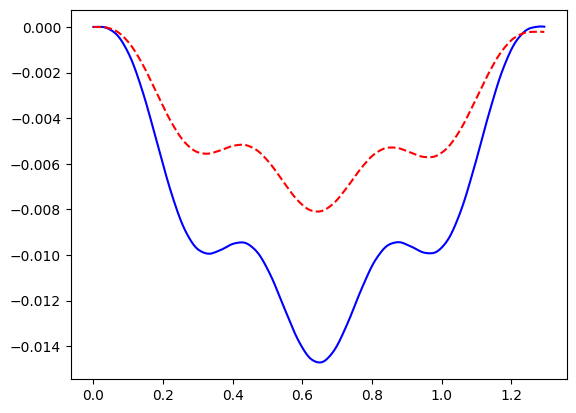

In [17]:
plt.plot(t, w, label='Midpoint Deflection (Constant Force)', color='blue')
plt.plot(t2, w2, label='Midpoint Deflection (FEM)', color='red', linestyle='--')

print(f"Max Deflection (w): {np.min(w):.4f} m")
print(f"Max Deflection (w2): {np.min(w2):.4f} m")
print(np.min(w) / np.min(w2))